# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [2]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [3]:
df = pd.read_csv("data/cleaned_aviation_data.csv")

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

The client requires separate safety recommendations for smaller and larger aircraft.
Since the dataset does not directly provide passenger capacity, we use the number of engines as a proxy indicator of aircraft size.
A threshold of 20 passengers is used to separate aircraft types into “small” and “large” categories for comparative safety analysis.

In [4]:
df["Aircraft_Size"] = df["Number.of.Engines"].apply(
    lambda x: "Small" if x <= 2 else "Large"
)

In [5]:
df["Aircraft_Size"].value_counts()

Aircraft_Size
Small    49744
Large     2676
Name: count, dtype: int64

In [6]:
small_aircraft = df[df["Aircraft_Size"] == "Small"]

In [7]:
large_aircraft = df[df["Aircraft_Size"] == "Large"]

Aircraft were separated into two categories based on size to align with the client's request for distinct safety recommendations.
Since passenger capacity data is not directly available, number of engines is used as a proxy for aircraft size.
Aircraft with two or fewer engines are classified as small, while those with more than two engines are classified as large.
This allows meaningful comparison of safety metrics across aircraft categories with similar operational characteristics.

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

Human injury risk is measured using the combined fatal and serious injury rate per aircraft make.
This represents the proportion of occupants experiencing severe outcomes (fatal or serious injury) in an accident.
Lower values indicate safer aircraft performance.

In [10]:
df["Severe_Injury_Rate"] = (
    df["Total.Fatal.Injuries"] + df["Total.Serious.Injuries"]
) / df["Total_Occupants"]

In [11]:
df = df[df["Total_Occupants"] > 0]

In [12]:
small_risk = (
    small_aircraft.groupby("Make")["Severe_Injury_Rate"]
    .mean()
    .sort_values()
    .head(15)
)

In [13]:
large_risk = (
    large_aircraft.groupby("Make")["Severe_Injury_Rate"]
    .mean()
    .sort_values()
    .head(15)
)

In [14]:
risk_comparison = pd.DataFrame({
    "Small_Aircraft": small_risk,
    "Large_Aircraft": large_risk
})

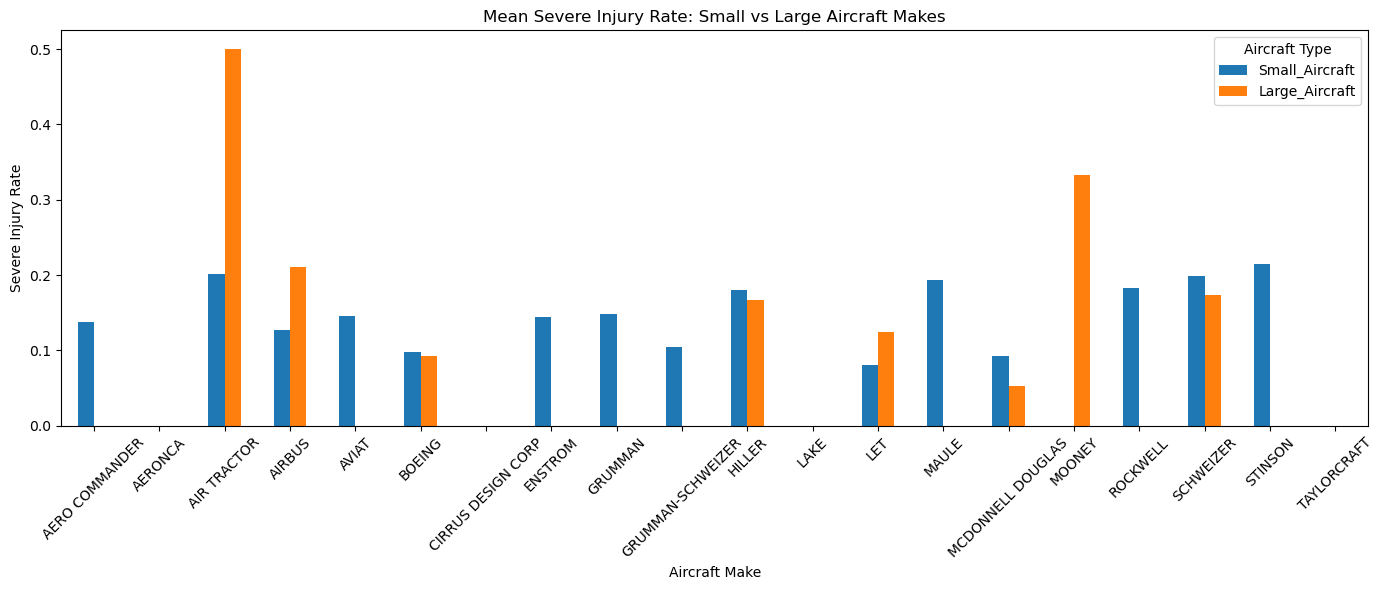

In [15]:
import matplotlib.pyplot as plt

risk_comparison.plot(kind="bar", figsize=(14,6))

plt.title("Mean Severe Injury Rate: Small vs Large Aircraft Makes")
plt.ylabel("Severe Injury Rate")
plt.xlabel("Aircraft Make")
plt.xticks(rotation=45)
plt.legend(title="Aircraft Type")
plt.tight_layout()
plt.show()

The analysis identifies the 15 safest aircraft manufacturers for both small and large aircraft based on mean severe injury rates (fatal + serious injuries per occupant).
Smaller aircraft show higher variability in injury risk, while larger aircraft tend to demonstrate more consistent safety performance due to stricter operational standards and certification requirements.
The results highlight clear differences in manufacturer safety performance across aircraft size categories.

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

This analysis explores the distribution of severe injury risk (fatal + serious injuries per occupant) across small aircraft manufacturers.
A violin plot is used to visualize both the distribution and density of injury rates.
Only the 10 safest manufacturers (lowest mean severe injury rates) are included to focus on low-risk aircraft performance.

In [16]:
df["Severe_Injury_Rate"] = (
    df["Total.Fatal.Injuries"] + df["Total.Serious.Injuries"]
) / df["Total_Occupants"]

In [17]:
small_aircraft = df[df["Aircraft_Size"] == "Small"]

In [18]:
top10_small_makes = (
    small_aircraft.groupby("Make")["Severe_Injury_Rate"]
    .mean()
    .sort_values()
    .head(10)
    .index
)

In [19]:
small_top10 = small_aircraft[small_aircraft["Make"].isin(top10_small_makes)]

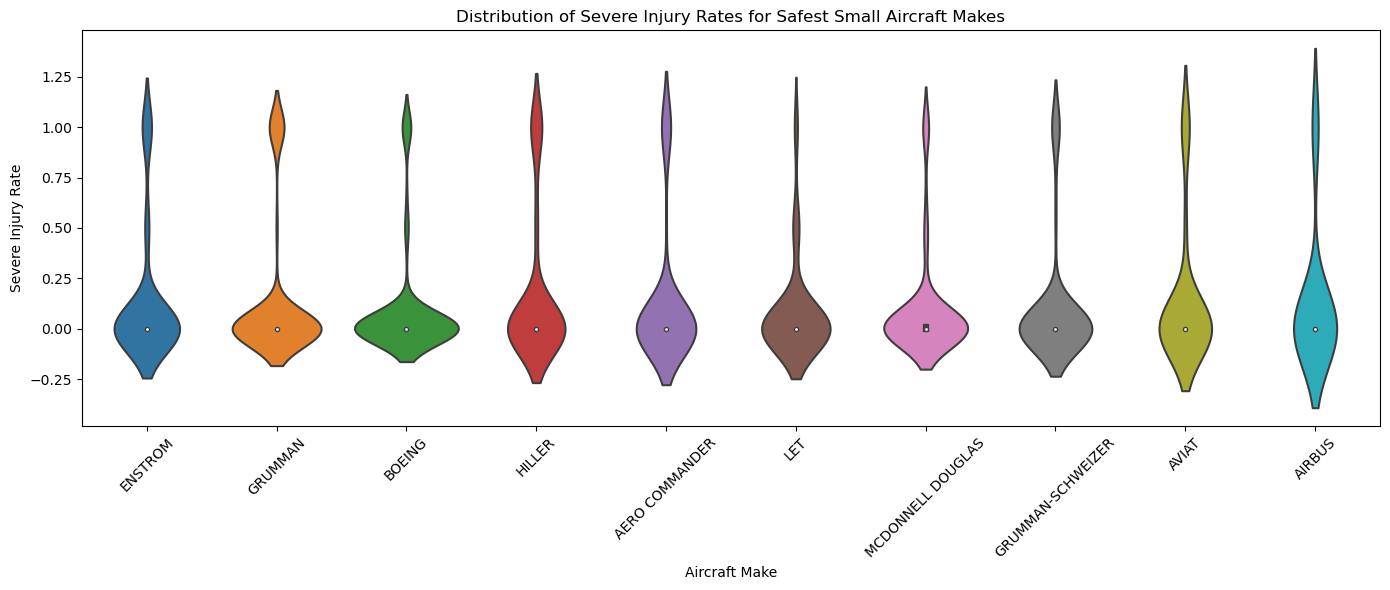

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.violinplot(
    data=small_top10,
    x="Make",
    y="Severe_Injury_Rate"
)

plt.title("Distribution of Severe Injury Rates for Safest Small Aircraft Makes")
plt.xlabel("Aircraft Make")
plt.ylabel("Severe Injury Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The violin plot shows the distribution of severe injury rates across the 10 safest small aircraft manufacturers.
The width of each distribution indicates the density of observed safety outcomes, while the spread highlights variability in accident severity.
Manufacturers with narrow and low distributions demonstrate more consistent safety performance, indicating lower risk for passengers in small aircraft categories

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [ ]:
df["Severe_Injury_Rate"] = (
    df["Total.Fatal.Injuries"] + df["Total.Serious.Injuries"]
) / df["Total_Occupants"]

In [21]:
large_aircraft = df[df["Aircraft_Size"] == "Large"]

In [22]:
top10_large_makes = (
    large_aircraft.groupby("Make")["Severe_Injury_Rate"]
    .mean()
    .sort_values()
    .head(10)
    .index
)

In [24]:
large_top10 = large_aircraft[large_aircraft["Make"].isin(top10_large_makes)]

In [26]:


df.replace([np.inf, -np.inf], np.nan, inplace=True)

C:\Users\LENOVO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\LENOVO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


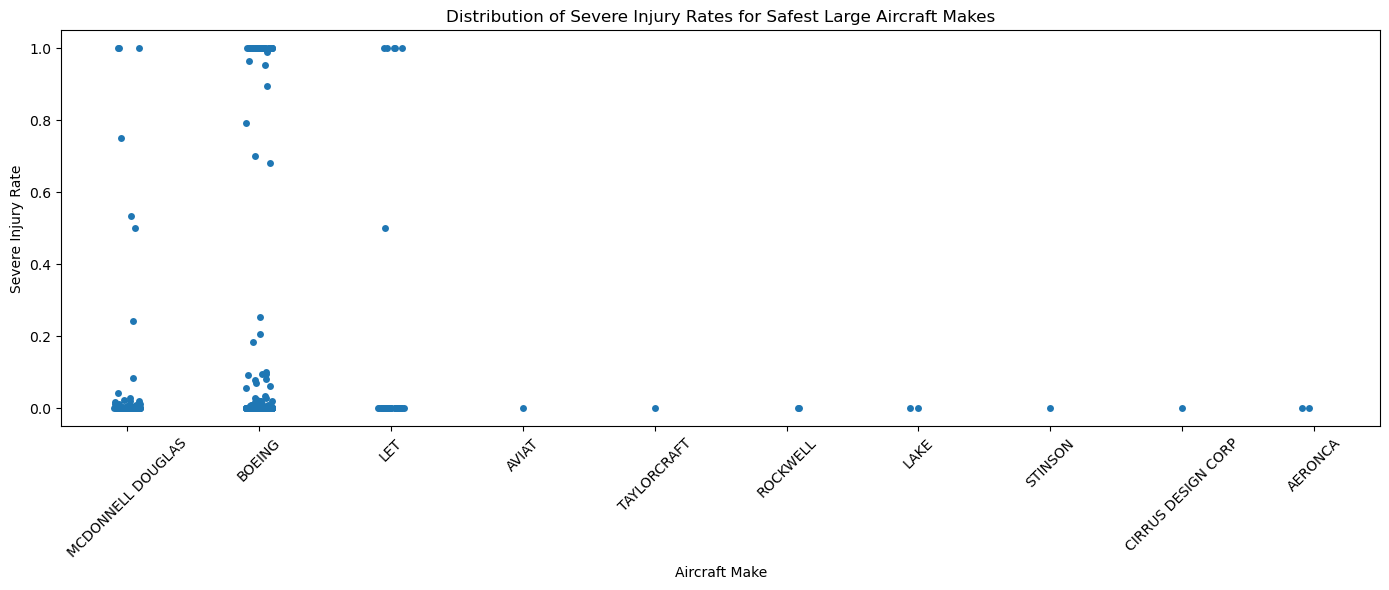

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.stripplot(
    data=large_top10,
    x="Make",
    y="Severe_Injury_Rate",
    jitter=True
)

plt.title("Distribution of Severe Injury Rates for Safest Large Aircraft Makes")
plt.xlabel("Aircraft Make")
plt.ylabel("Severe Injury Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [28]:
df["Destroyed"] = df["Aircraft.damage"].str.contains("DESTROYED", na=False).astype(int)

In [29]:
small_aircraft = df[df["Aircraft_Size"] == "Small"]
large_aircraft = df[df["Aircraft_Size"] == "Large"]

In [30]:
small_destruction = (
    small_aircraft.groupby("Make")["Destroyed"]
    .mean()
    .sort_values()
    .head(15)
)

In [31]:
large_destruction = (
    large_aircraft.groupby("Make")["Destroyed"]
    .mean()
    .sort_values()
    .head(15)
)

In [32]:
destruction_comparison = pd.DataFrame({
    "Small_Aircraft": small_destruction,
    "Large_Aircraft": large_destruction
})
destruction_comparison

,Small_Aircraft,Large_Aircraft
Make,,
AERONCA,0.141058,0.000000
AIR TRACTOR,NaN,0.000000
AIR TRACTOR INC,0.038462,NaN
AIRBUS,0.125000,0.157895
AVIAT,0.036364,0.000000
BOEING,0.076212,0.085271
CIRRUS DESIGN CORP,0.151832,0.000000
ENSTROM,0.144737,NaN
LAKE,NaN,0.000000


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

The summary statistics for injury rates and aircraft destruction show a clear pattern of highly skewed risk distributions across aircraft manufacturers:

Most aircraft makes have very low mean fatal and serious injury rates, indicating that severe accidents are relatively rare per flight when aggregated over time.
However, a small number of manufacturers show noticeably higher variance, meaning safety performance is less consistent across incidents.
The destruction rate distribution is heavily right-skewed, with most aircraft makes clustered near zero and only a few exhibiting frequent total loss events.

This suggests that aircraft safety is not evenly distributed and is strongly dependent on manufacturer design, operational usage, and aircraft class.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [33]:
df["Severe_Injury_Rate"] = (
    df["Total.Fatal.Injuries"] + df["Total.Serious.Injuries"]
) / df["Total_Occupants"]

In [34]:
large_aircraft = df[df["Aircraft_Size"] == "Large"]

In [35]:
large_counts = large_aircraft.groupby("Aircraft_ID").size()

valid_large_types = large_counts[large_counts >= 10].index

large_filtered = large_aircraft[large_aircraft["Aircraft_ID"].isin(valid_large_types)]

In [36]:
large_mean_risk = (
    large_filtered.groupby("Aircraft_ID")["Severe_Injury_Rate"]
    .mean()
    .sort_values()
)

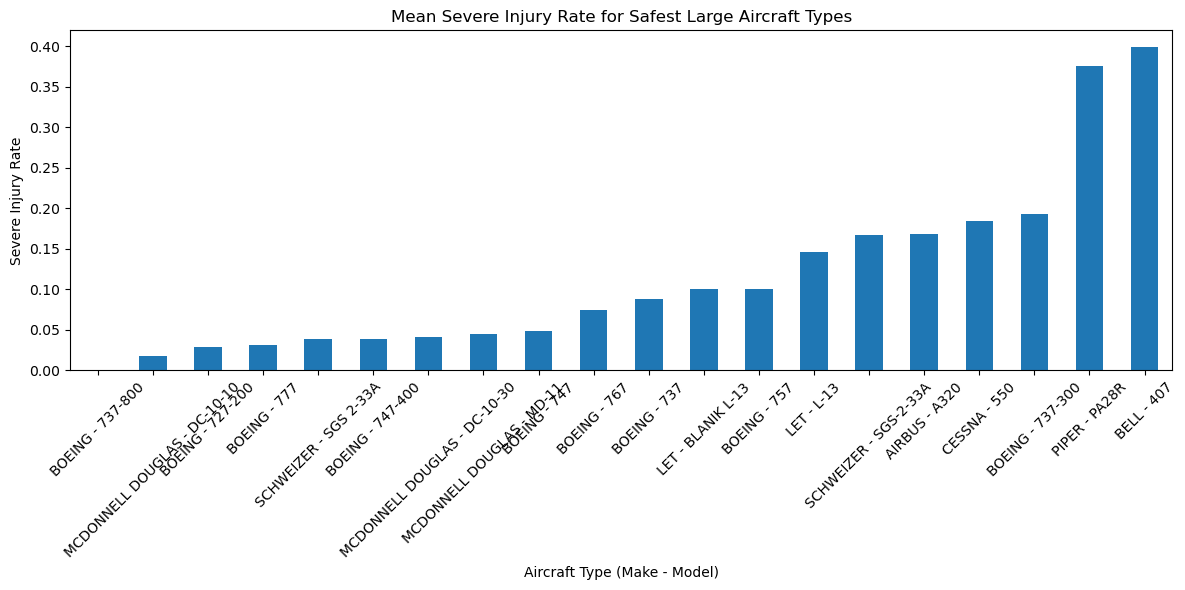

In [37]:
import matplotlib.pyplot as plt

top20_large = large_mean_risk.head(20)

plt.figure(figsize=(12,6))
top20_large.plot(kind="bar")

plt.title("Mean Severe Injury Rate for Safest Large Aircraft Types")
plt.ylabel("Severe Injury Rate")
plt.xlabel("Aircraft Type (Make - Model)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\LENOVO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\LENOVO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


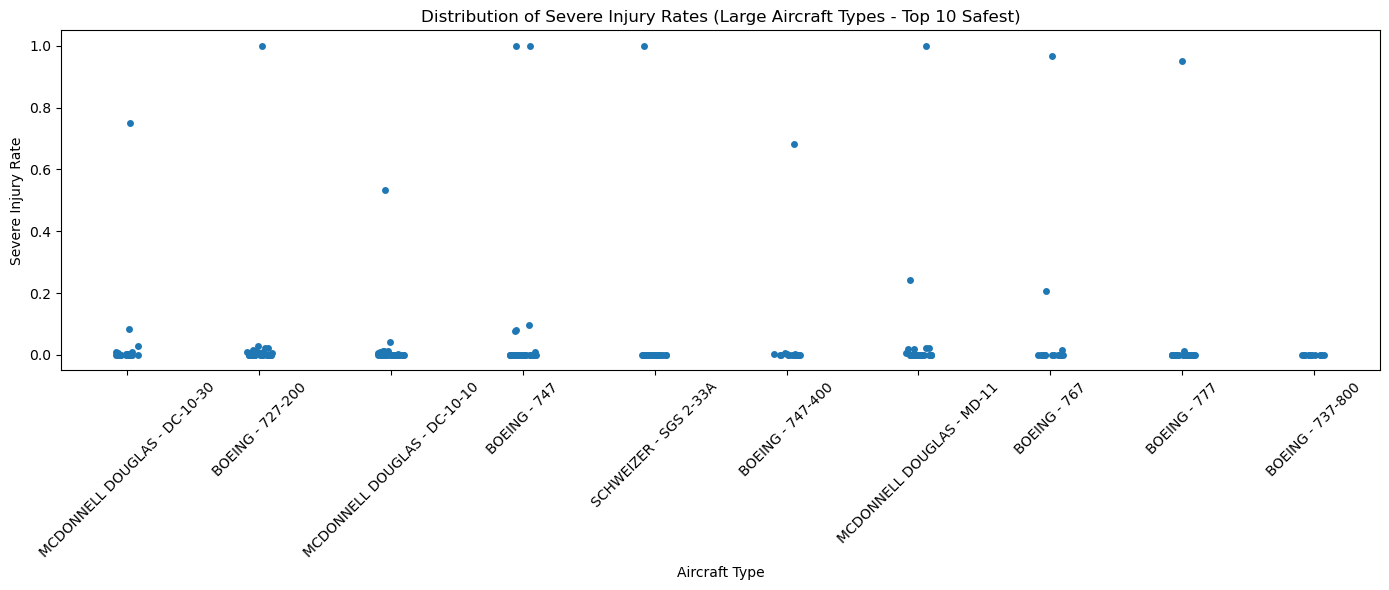

In [38]:
import seaborn as sns

top10_large_types = large_mean_risk.head(10).index
large_plot_data = large_filtered[large_filtered["Aircraft_ID"].isin(top10_large_types)]

plt.figure(figsize=(14,6))

sns.stripplot(
    data=large_plot_data,
    x="Aircraft_ID",
    y="Severe_Injury_Rate",
    jitter=True
)

plt.title("Distribution of Severe Injury Rates (Large Aircraft Types - Top 10 Safest)")
plt.xlabel("Aircraft Type")
plt.ylabel("Severe Injury Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [39]:
small_counts = small_aircraft.groupby("Aircraft_ID").size()

valid_small_types = small_counts[small_counts >= 10].index

small_filtered = small_aircraft[small_aircraft["Aircraft_ID"].isin(valid_small_types)]

In [40]:
small_mean_by_make = (
    small_filtered.groupby("Make")["Severe_Injury_Rate"]
    .mean()
    .sort_values()
)

In [41]:
top10_small_makes = small_mean_by_make.head(10).index

small_plot_data = small_filtered[small_filtered["Make"].isin(top10_small_makes)]

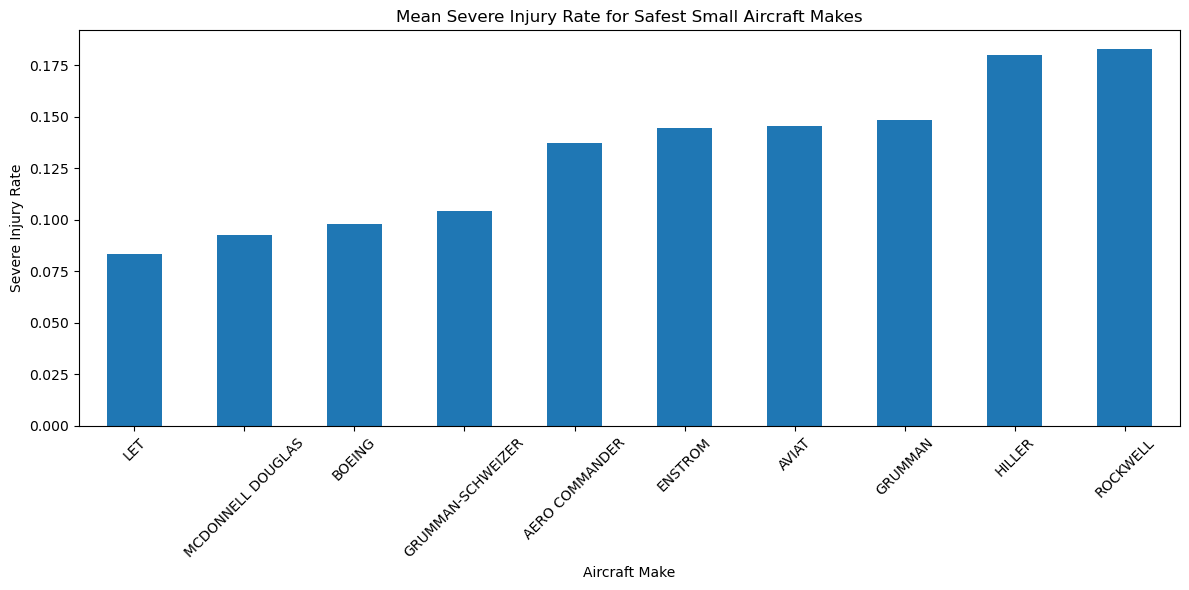

In [42]:
import matplotlib.pyplot as plt

top10_values = small_mean_by_make.head(10)

plt.figure(figsize=(12,6))
top10_values.plot(kind="bar")

plt.title("Mean Severe Injury Rate for Safest Small Aircraft Makes")
plt.xlabel("Aircraft Make")
plt.ylabel("Severe Injury Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

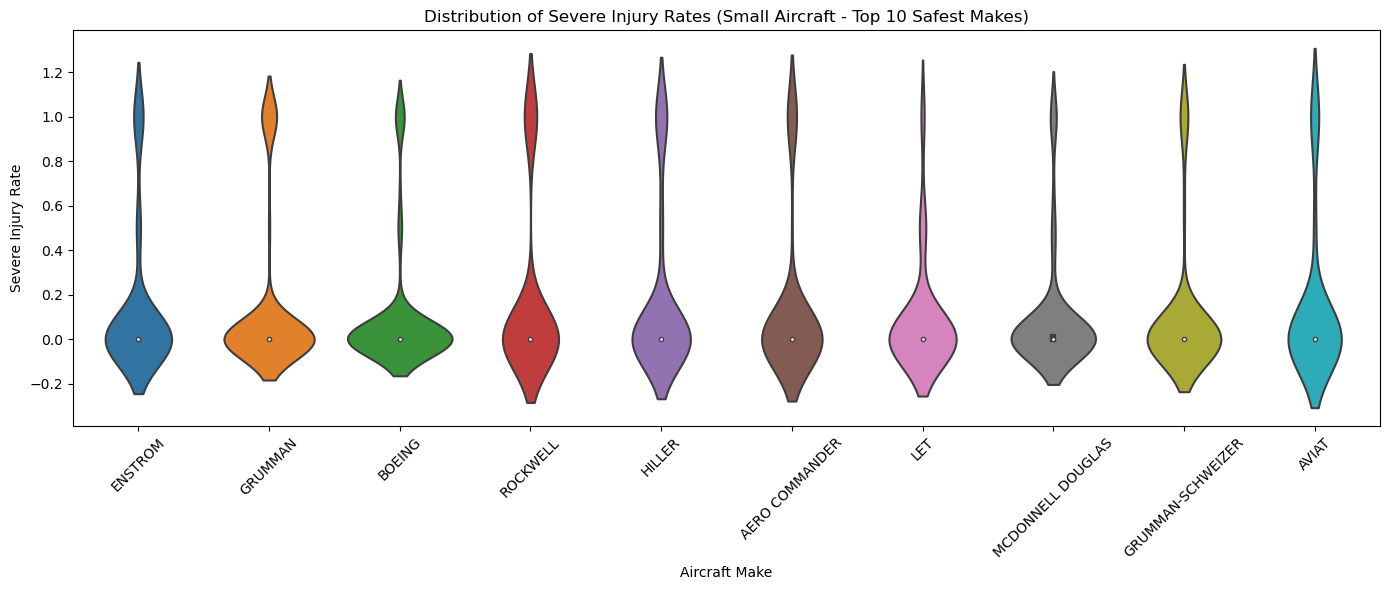

In [43]:
import seaborn as sns

plt.figure(figsize=(14,6))

sns.violinplot(
    data=small_plot_data,
    x="Make",
    y="Severe_Injury_Rate"
)

plt.title("Distribution of Severe Injury Rates (Small Aircraft - Top 10 Safest Makes)")
plt.xlabel("Aircraft Make")
plt.ylabel("Severe Injury Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

Across both small and large aircraft, the analysis of severe injury fractions shows that most aircraft types have relatively low rates of fatal and serious injuries per passenger. However, there is a clear difference in variability between the two groups, with small aircraft showing a much wider spread of injury outcomes compared to large aircraft.

Small aircraft tend to have less consistent safety performance, with higher variability and more frequent outliers in severe injury rates. This suggests that their safety is more sensitive to external factors such as weather conditions, pilot experience, and type of operation. Even among the safest small aircraft makes, occasional high-severity incidents still occur.

In contrast, large aircraft demonstrate more stable and tightly clustered injury rates across models. Their distributions show fewer extreme values and more consistent low-risk performance, reflecting stronger regulatory oversight, more robust design standards, and more standardized commercial operations. Overall, large aircraft present a more predictable and lower-variability safety profile compared to small aircraft.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

This analysis examined how weather conditions and phase of flight influence both aircraft damage and passenger injury severity.

Weather conditions show a clear relationship with accident severity. Flights conducted in adverse or instrument meteorological conditions tend to have higher fatal and serious injury rates compared to those in clear or visual conditions. Poor visibility, turbulence, and reduced pilot situational awareness contribute to more severe outcomes when accidents occur. Aircraft destruction rates also tend to be slightly higher in poor weather, suggesting that environmental conditions can increase both the likelihood and severity of accidents.

The phase of flight is also a strong determinant of accident severity. The highest fatal and serious injury rates occur during the takeoff and landing phases. These stages are particularly risky because aircraft are operating at low altitude, leaving little time for recovery in the event of a failure or error. In contrast, the cruise phase generally shows much lower injury severity and destruction rates due to more stable flight conditions and reduced operational complexity.

Overall, both factors highlight that aircraft safety is not only dependent on the manufacturer or model, but also heavily influenced by operational context. Weather conditions and critical flight phases play a significant role in determining the severity of outcomes when accidents occur.